In [2]:
import pandas as pd
import numpy as np

iri = pd.read_excel("MON_HSS_PROFILE_SECTION.xlsx")
trf1 = pd.read_excel("TRF_TREND_1.xlsx")
trf2 = pd.read_excel("TRF_TREND.xlsx")

print(iri.shape, trf1.shape, trf2.shape)

(65534, 11) (65534, 7) (65534, 7)


In [3]:
# Convert date and extract year
iri['VISIT_DATE'] = pd.to_datetime(iri['VISIT_DATE'])
iri['YEAR'] = iri['VISIT_DATE'].dt.year

# Drop columns we don't need
iri = iri.drop(columns=['IRI_CENTER_LANE', 'VISIT_DATE', 'VISIT_NO', 'RUN_NUMBER'])

# Average multiple runs per section per year
iri_clean = iri.groupby(
    ['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR'])['MRI'].mean().reset_index()

print("Shape:", iri_clean.shape)
print("Unique sections:", iri_clean['SHRP_ID'].nunique())
print("Year range:", iri_clean['YEAR'].min(), "to", iri_clean['YEAR'].max())
print(iri_clean.head(5))

Shape: (11815, 5)
Unique sections: 502
Year range: 1989 to 2023
  SHRP_ID  STATE_CODE  CONSTRUCTION_NO  YEAR      MRI
0    0101           1                1  1995  0.65720
1    0101           1                1  1996  0.68120
2    0101           1                1  1997  0.69480
3    0101           1                1  1998  0.73825
4    0101           1                1  1999  0.71360


In [4]:
# Clean traffic files
trf1['YEAR'] = trf1['YEAR'].astype(int)
trf2['YEAR'] = trf2['YEAR'].astype(int)

# Merge both traffic files
trf_merged = pd.merge(
    trf1[['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR', 
          'AADTT_ALL_TRUCKS_TREND', 'ANNUAL_TRUCK_VOLUME_TREND']],
    trf2[['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR', 
          'ANNUAL_ESAL_TREND']],
    on=['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR'],
    how='inner'
)

# Merge with IRI
df = pd.merge(
    iri_clean,
    trf_merged,
    on=['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR'],
    how='inner'
)

# Drop nulls
df = df.dropna()

print("Shape:", df.shape)
print("Unique sections:", df['SHRP_ID'].nunique())
print("\nNull values:\n", df.isnull().sum())
print(df.head(5))

Shape: (11729, 8)
Unique sections: 502

Null values:
 SHRP_ID                      0
STATE_CODE                   0
CONSTRUCTION_NO              0
YEAR                         0
MRI                          0
AADTT_ALL_TRUCKS_TREND       0
ANNUAL_TRUCK_VOLUME_TREND    0
ANNUAL_ESAL_TREND            0
dtype: int64
  SHRP_ID  STATE_CODE  CONSTRUCTION_NO  YEAR      MRI  AADTT_ALL_TRUCKS_TREND  \
0    0101           1                1  1995  0.65720                     775   
1    0101           1                1  1996  0.68120                     798   
2    0101           1                1  1997  0.69480                     822   
3    0101           1                1  1998  0.73825                     847   
4    0101           1                1  1999  0.71360                     872   

   ANNUAL_TRUCK_VOLUME_TREND  ANNUAL_ESAL_TREND  
0                     282875           273378.0  
1                     292068           282051.0  
2                     300030           290591.0 

In [5]:
# Sort by section and year
df = df.sort_values(['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO', 'YEAR']).reset_index(drop=True)

# 1. Cumulative ESAL (total damage load experienced so far)
df['CUMULATIVE_ESAL'] = df.groupby(
    ['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO'])['ANNUAL_ESAL_TREND'].cumsum()

# 2. IRI Growth Rate per section (using loop to avoid groupby issues)
iri_slope = {}
for (shrp, state, cn), group in df.groupby(['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO']):
    if len(group) >= 2:
        slope = np.polyfit(group['YEAR'], group['MRI'], 1)[0]
        iri_slope[(shrp, state, cn)] = slope

df['IRI_GROWTH_RATE'] = df.apply(
    lambda row: iri_slope.get(
        (row['SHRP_ID'], row['STATE_CODE'], row['CONSTRUCTION_NO']), np.nan), axis=1)

# 3. Target: IRI at next measurement
df['FUTURE_IRI'] = df.groupby(
    ['SHRP_ID', 'STATE_CODE', 'CONSTRUCTION_NO'])['MRI'].shift(-1)

# Drop rows without future IRI
df = df.dropna(subset=['FUTURE_IRI', 'IRI_GROWTH_RATE'])

print("Final shape:", df.shape)
print("\nSample:")
print(df[['SHRP_ID', 'YEAR', 'MRI', 'FUTURE_IRI', 'IRI_GROWTH_RATE', 'CUMULATIVE_ESAL']].head(8))
print("\nFuture IRI stats:\n", df['FUTURE_IRI'].describe())

Final shape: (8925, 11)

Sample:
  SHRP_ID  YEAR      MRI  FUTURE_IRI  IRI_GROWTH_RATE  CUMULATIVE_ESAL
0    0101  1995  0.65720     0.68120         0.009959         273378.0
1    0101  1996  0.68120     0.69480         0.009959         555429.0
2    0101  1997  0.69480     0.73825         0.009959         846020.0
3    0101  1998  0.73825     0.71360         0.009959        1145696.0
4    0101  1999  0.71360     0.74300         0.009959        1453683.0
5    0101  2001  0.74300     0.70580         0.009959        1780511.0
6    0101  2002  0.70580     0.73160         0.009959        2117191.0
7    0101  2003  0.73160     0.77560         0.009959        2463956.0

Future IRI stats:
 count    8925.000000
mean        1.339954
std         0.587049
min         0.319600
25%         0.924600
50%         1.224200
75%         1.612600
max         5.867800
Name: FUTURE_IRI, dtype: float64


In [6]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Features and target
features = ['MRI', 'AADTT_ALL_TRUCKS_TREND', 'ANNUAL_TRUCK_VOLUME_TREND',
            'ANNUAL_ESAL_TREND', 'CUMULATIVE_ESAL', 'IRI_GROWTH_RATE', 'YEAR']
target = 'FUTURE_IRI'

X = df[features]
y = df[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train XGBoost
model = XGBRegressor(n_estimators=200, learning_rate=0.05, 
                     max_depth=6, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("MAE:", round(mean_absolute_error(y_test, y_pred), 4))
print("R2 Score:", round(r2_score(y_test, y_pred), 4))

MAE: 0.0768
R2 Score: 0.9411


In [7]:
FAILURE_THRESHOLD = 2.5

# Predict future IRI on full dataset
df['PREDICTED_FUTURE_IRI'] = model.predict(df[features])

# Compute RUL: how many years until predicted IRI hits threshold
# Using IRI growth rate to project forward
df['RUL'] = df.apply(
    lambda row: (FAILURE_THRESHOLD - row['PREDICTED_FUTURE_IRI']) / row['IRI_GROWTH_RATE']
    if row['IRI_GROWTH_RATE'] > 0 
    else 50, axis=1)

df['RUL'] = df['RUL'].clip(0, 50)

print(df[['SHRP_ID', 'YEAR', 'MRI', 'PREDICTED_FUTURE_IRI', 'RUL']].head(10))
print("\nRUL stats:\n", df['RUL'].describe())

   SHRP_ID  YEAR      MRI  PREDICTED_FUTURE_IRI   RUL
0     0101  1995  0.65720              0.649882  50.0
1     0101  1996  0.68120              0.696979  50.0
2     0101  1997  0.69480              0.717485  50.0
3     0101  1998  0.73825              0.743010  50.0
4     0101  1999  0.71360              0.726206  50.0
5     0101  2001  0.74300              0.759115  50.0
6     0101  2002  0.70580              0.725949  50.0
7     0101  2003  0.73160              0.758365  50.0
8     0101  2004  0.77560              0.801597  50.0
10    0101  1997  0.83630              0.866439  50.0

RUL stats:
 count    8925.000000
mean       37.727380
std        17.202343
min         0.000000
25%        25.008729
50%        50.000000
75%        50.000000
max        50.000000
Name: RUL, dtype: float64


In [8]:
# Rate = difference between predicted future IRI and current IRI
df['IRI_CHANGE_RATE'] = df['PREDICTED_FUTURE_IRI'] - df['MRI']

# RUL = how many years at this rate to hit threshold
df['RUL'] = df.apply(
    lambda row: (FAILURE_THRESHOLD - row['MRI']) / row['IRI_CHANGE_RATE']
    if row['IRI_CHANGE_RATE'] > 0
    else 50, axis=1)

df['RUL'] = df['RUL'].clip(0, 50)

print(df[['SHRP_ID', 'YEAR', 'MRI', 'PREDICTED_FUTURE_IRI', 'IRI_CHANGE_RATE', 'RUL']].head(10))
print("\nRUL stats:\n", df['RUL'].describe())
print("\nRUL distribution:")
print(pd.cut(df['RUL'], bins=[0,10,20,30,40,50]).value_counts().sort_index())

   SHRP_ID  YEAR      MRI  PREDICTED_FUTURE_IRI  IRI_CHANGE_RATE   RUL
0     0101  1995  0.65720              0.649882        -0.007318  50.0
1     0101  1996  0.68120              0.696979         0.015779  50.0
2     0101  1997  0.69480              0.717485         0.022685  50.0
3     0101  1998  0.73825              0.743010         0.004760  50.0
4     0101  1999  0.71360              0.726206         0.012606  50.0
5     0101  2001  0.74300              0.759115         0.016115  50.0
6     0101  2002  0.70580              0.725949         0.020149  50.0
7     0101  2003  0.73160              0.758365         0.026765  50.0
8     0101  2004  0.77560              0.801597         0.025997  50.0
10    0101  1997  0.83630              0.866439         0.030139  50.0

RUL stats:
 count    8925.000000
mean       34.592454
std        17.936809
min         0.000000
25%        17.520127
50%        46.703155
75%        50.000000
max        50.000000
Name: RUL, dtype: float64

RUL distrib

Model saved!


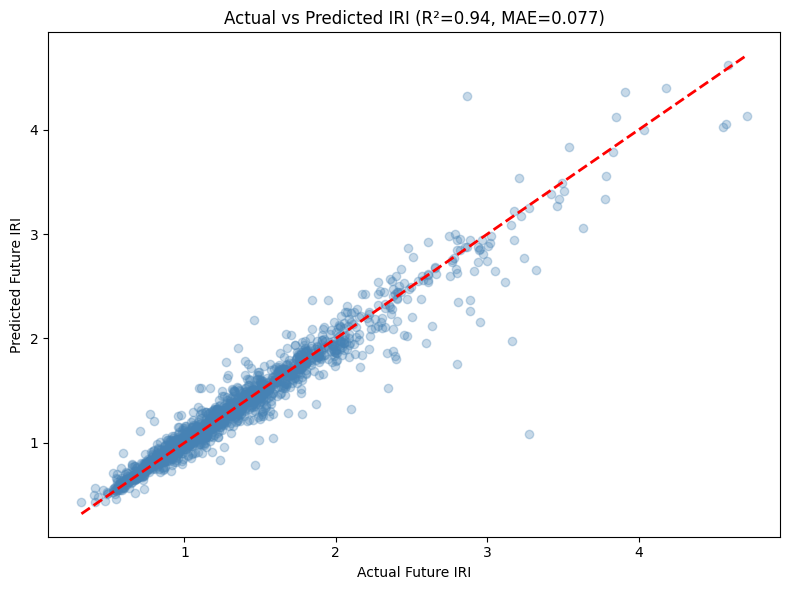

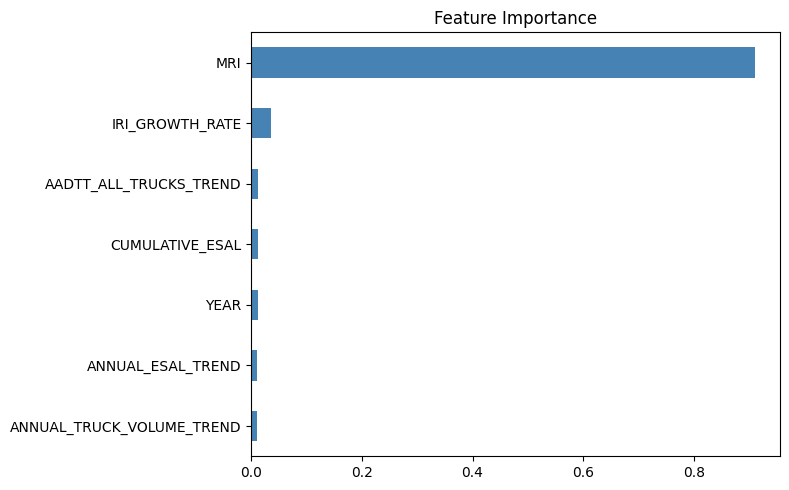

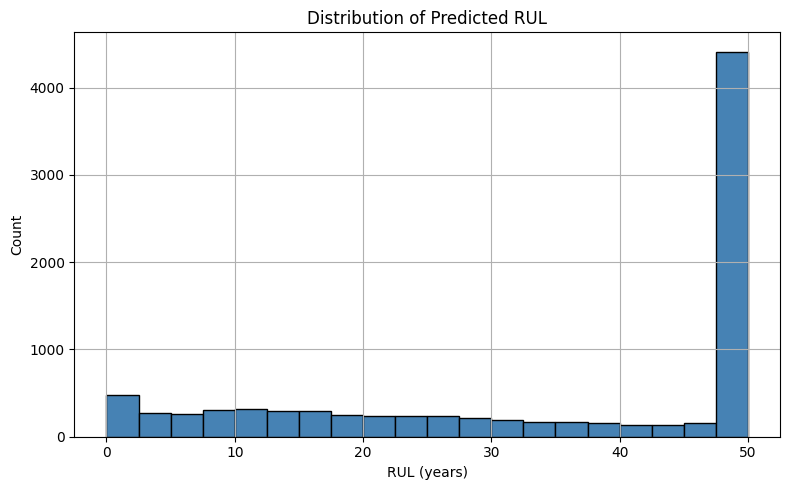

In [9]:
import matplotlib.pyplot as plt
import joblib

# 1. Save the model
joblib.dump(model, 'iri_prediction_model.pkl')
print("Model saved!")

# 2. Actual vs Predicted IRI plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Future IRI")
plt.ylabel("Predicted Future IRI")
plt.title(f"Actual vs Predicted IRI (R²=0.94, MAE=0.077)")
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

# 3. Feature Importance plot
plt.figure(figsize=(8,5))
feat_imp = pd.Series(model.feature_importances_, index=features).sort_values()
feat_imp.plot(kind='barh', color='steelblue')
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# 4. RUL distribution plot
plt.figure(figsize=(8,5))
df['RUL'].hist(bins=20, color='steelblue', edgecolor='black')
plt.xlabel("RUL (years)")
plt.ylabel("Count")
plt.title("Distribution of Predicted RUL")
plt.tight_layout()
plt.savefig('rul_distribution.png', dpi=150)
plt.show()